# TFG — Predicción del Riesgo de Insolvencia Sectorial en PYMEs 
## Construcción del Dataset y Análisis Exploratorio

**Autora:** Natalia Arranz 
**Universidad Francisco de Vitoria — Curso 2025/2026**

---

### Descripción
Este notebook recoge el proceso completo de construcción del dataset final utilizado en el TFG,
desde la carga y limpieza de las fuentes originales hasta el análisis exploratorio de los datos (EDA).

El dataset resultante contiene **58 observaciones trimestrales** (2011Q3–2025Q2) y **17 variables**,
combinando datos públicos de INE, Banco de España, OMIE y Eurostat.

### Estructura del notebook
1. Carga y limpieza de fuentes individuales
2. Integración del dataset final
3. Análisis Exploratorio (EDA)
   - Estadísticos descriptivos
   - Evolución temporal
   - Outliers e histogramas
   - Matriz de correlaciones
   - Test de estacionariedad (ADF)

## LIMPIEZA DATASET CONCURSOS

In [31]:
import pandas as pd
import numpy as np

# ── FUNCIÓN PARA PARSEAR NÚMEROS EN FORMATO INE ────────────────────────────────
# El INE mezcla dos formatos: "1.568" (sep miles) y "913.000" (decimal con ceros)
def parse_num_ine_v2(val):
    s = str(val).strip()
    if s in ['nan', '', '-']:
        return np.nan
    if '.' in s:
        partes = s.split('.')
        parte_decimal = partes[-1]
        parte_entera = partes[0]
        if parte_decimal.rstrip('0') == '' and len(parte_entera) >= 3:
            return float(parte_entera)
        else:
            return float(s.replace('.', ''))
    return float(s)

# ── 1. CARGA Y LIMPIEZA: CONCURSOS ANTIGUO (2011–2020) ────────────────────────
df_ant = pd.read_csv(
    "../data/raw/data_rawINE_concursos_empresas_sector_antiguo_trimestral.csv",
    encoding='latin1',
    sep=';',
    dtype={'Total': str} 
)

# Filtrar solo datos nacionales
df_ant = df_ant[df_ant['Totales Territoriales'] == 'Nacional'].copy()

# Corregir formato numérico
df_ant['Total'] = df_ant['Total'].apply(parse_num_ine_v2)

# Quedarse solo con sectores principales (sin subsectores para no duplicar)
sectores_principales = [
    'Total',
    'A Agricultura y pesca',
    'Industria y energía',
    'F Construcción',
    'G Comercio',
    'H Transporte y almacenamiento',
    'I Hostelería',
    'J Información y comunicaciones',
    'Inmobiliarias financieras y seguros',
    'M Actividades profesionales y técnicas',
    'N Actividades administrativas y servicios auxiliares',
    'Resto de servicios'
]

df_ant = df_ant[df_ant['Actividad económica'].isin(sectores_principales)][
    ['Periodo', 'Actividad económica', 'Total']
].rename(columns={
    'Actividad económica': 'sector',
    'Total': 'concursos',
    'Periodo': 'periodo'
})

# Formato de periodo: 2011T1 → 2011Q1
df_ant['periodo'] = df_ant['periodo'].str.replace('T', 'Q')
df_ant['concursos'] = df_ant['concursos'].astype(int)

print(f"Antiguo cargado: {df_ant.shape[0]} filas | {df_ant['periodo'].min()} → {df_ant['periodo'].max()}")


# ── 2. CARGA Y LIMPIEZA: CONCURSOS NUEVO (2021–2025) ──────────────────────────
raw = pd.read_excel(
    "../data/raw/data_rawINE_concursos_empresas_sector_nuevo_trimestral.xlsx",
    header=None
)

# Extraer periodos (fila 6) y datos (filas 8–26)
periodos_raw = [x for x in raw.iloc[6, 1:].tolist() if str(x) != 'nan']
sectores_raw = [str(x).strip() for x in raw.iloc[8:27, 0].tolist() if str(x) != 'nan']
datos = raw.iloc[8:27, 1:len(periodos_raw)+1].values

# Convertir formato de periodo: 2021/I → 2021Q1
def convertir_periodo(p):
    p = str(p).strip()
    for romano, num in [('/IV','Q4'), ('/III','Q3'), ('/II','Q2'), ('/I','Q1')]:
        p = p.replace(romano, num)
    return p.replace('/', '')

periodos = [convertir_periodo(p) for p in periodos_raw]

# Mapeo de sectores gallego/CNAE-09 → categorías del archivo antiguo
mapa_sectores = {
    'Agricultura, gandería, silvicultura e pesca':            'A Agricultura y pesca',
    'Industrias extractivas':                                  'Industria y energía',
    'Industrias manufactureiras':                              'Industria y energía',
    'Subministro de enerxía eléctrica, gas, vapor e aire acondicionado': 'Industria y energía',
    'Subministro de auga, actividades de saneamento, xestión de residuos e descontaminación': 'Industria y energía',
    'Construción':                                             'F Construcción',
    'Comercio por xunto e polo miúdo, reparación de vehículos de motor e motocicletas': 'G Comercio',
    'Transporte e almacenamento':                             'H Transporte y almacenamiento',
    'Hostelaría':                                              'I Hostelería',
    'Información e comunicacións':                            'J Información y comunicaciones',
    'Actividades financeiras e de seguros':                   'Inmobiliarias financieras y seguros',
    'Actividades inmobiliarias':                              'Inmobiliarias financieras y seguros',
    'Actividades profesionales, científicas e técnicas':      'M Actividades profesionales y técnicas',
    'Actividades administrativas e servizos auxiliares':      'N Actividades administrativas y servicios auxiliares',
    'Administración Pública e defensa; Seguridade Social obrigatoria': 'Resto de servicios',
    'Educación':                                               'Resto de servicios',
    'Actividades sanitarias e de servizos sociais':           'Resto de servicios',
    'Actividades artísticas, recreativas e de entretemento':  'Resto de servicios',
    'Outros servizos':                                         'Resto de servicios',
}

# Construir dataframe en formato largo
filas = []
for i, sector_orig in enumerate(sectores_raw):
    sector_dest = mapa_sectores.get(sector_orig)
    if not sector_dest:
        continue
    for j, periodo in enumerate(periodos):
        try:
            valor = int(float(datos[i, j]))
        except:
            valor = 0
        filas.append({'periodo': periodo, 'sector': sector_dest, 'concursos': valor})

df_new = pd.DataFrame(filas)

# Agregar por sector (suma subsectores que comparten categoría)
df_new = df_new.groupby(['periodo', 'sector'], as_index=False)['concursos'].sum()

# Añadir fila Total
total_new = df_new.groupby('periodo', as_index=False)['concursos'].sum()
total_new['sector'] = 'Total'
df_new = pd.concat([df_new, total_new], ignore_index=True)

print(f"Nuevo cargado: {df_new.shape[0]} filas | {df_new['periodo'].min()} → {df_new['periodo'].max()}")


# ── 3. MERGE: UNIR AMBOS ARCHIVOS ─────────────────────────────────────────────
df_concursos = pd.concat([df_ant, df_new], ignore_index=True)
df_concursos = df_concursos.sort_values(['sector', 'periodo']).reset_index(drop=True)

print(f"\nDataset final: {df_concursos.shape[0]} filas")
print(f"Periodos: {df_concursos['periodo'].min()} → {df_concursos['periodo'].max()}")
print(f"Sectores: {df_concursos['sector'].nunique()}")
print(f"Nulos: {df_concursos['concursos'].isna().sum()}")

df_concursos.head(15)

df_concursos.to_csv('../data/processed/concursos_sector_trimestral.csv', index=False)

Antiguo cargado: 480 filas | 2011Q1 → 2020Q4
Nuevo cargado: 240 filas | 2021Q1 → 2025Q4

Dataset final: 720 filas
Periodos: 2011Q1 → 2025Q4
Sectores: 12
Nulos: 0


# LIMPIEZA DATASET PARO

In [32]:
# ── CARGA Y LIMPIEZA: TASA DE PARO EPA (2011–2025) ────────────────────────────
df_paro_raw = pd.read_csv(
    "../data/raw/data_INE_EPA_paro_trimestral.csv",
    encoding='latin1',
    sep=None,
    engine='python'
)

# Renombrar primera columna (tiene BOM en el nombre)
df_paro_raw.columns = ['sexo', 'comunidad', 'nacionalidad', 'periodo', 'tasa_paro']

# Filtrar: Ambos sexos + Nacional + Total nacionalidad
df_paro = df_paro_raw[
    (df_paro_raw['sexo'] == 'Ambos sexos') &
    (df_paro_raw['comunidad'] == 'Total Nacional') &
    (df_paro_raw['nacionalidad'] == 'Total')
].copy()

# Corregir decimal (coma → punto) y convertir a float
df_paro['tasa_paro'] = df_paro['tasa_paro'].str.replace(',', '.').astype(float)

# Formato periodo: 2011T1 → 2011Q1
df_paro['periodo'] = df_paro['periodo'].str.replace('T', 'Q')

# Filtrar desde 2011
df_paro = df_paro[df_paro['periodo'] >= '2011Q1'][['periodo', 'tasa_paro']].reset_index(drop=True)

print(f"Paro cargado: {df_paro.shape[0]} filas | {df_paro['periodo'].min()} → {df_paro['periodo'].max()}")
print(df_paro.head())

# Guardar
df_paro.to_csv('../data/processed/paro_trimestral.csv', index=False)
print("Guardado en data/processed/paro_trimestral.csv")

Paro cargado: 60 filas | 2011Q1 → 2025Q4
  periodo  tasa_paro
0  2025Q4       9.93
1  2025Q3      10.45
2  2025Q2      10.29
3  2025Q1      11.36
4  2024Q4      10.61
Guardado en data/processed/paro_trimestral.csv


# LIMPIEZA DATASET DE MOROSIDAD

In [33]:
import pandas as pd
import numpy as np

# ── CARGA Y LIMPIEZA: MOROSIDAD BANCO DE ESPAÑA (2011–2025) ───────────────────
raw_mor = pd.read_excel(
    "../data/raw/data_rawBancoEspana_Morosidad_creditos_dudosos_empresas_por_actividad.xlsx",
    sheet_name='be0418',
    header=None
)

# Extraer solo filas de datos (desde fila 6, quitar FUENTE/NOTAS al final)
datos = raw_mor.iloc[6:, :].copy()
datos.columns = range(datos.shape[1])
datos = datos[datos[0].astype(str).str.match(r'[A-Z]+ \d{4}')].copy()

# Quedarse solo con meses de fin de trimestre (datos reales)
meses_trim = ['MAR', 'JUN', 'SEP', 'DIC']
datos = datos[datos[0].astype(str).str[:3].isin(meses_trim)].copy()

# Convertir fecha a formato trimestral: "MAR 2011" → "2011Q1"
mapa_mes_q = {'MAR': 'Q1', 'JUN': 'Q2', 'SEP': 'Q3', 'DIC': 'Q4'}
def fecha_a_trimestre(fecha):
    partes = str(fecha).split()
    return partes[1] + mapa_mes_q[partes[0]]

datos['periodo'] = datos[0].apply(fecha_a_trimestre)

# Filtrar desde 2011Q1
datos = datos[datos['periodo'] >= '2011Q1'].copy()

# Convertir columnas a numérico (reemplazar '-' por NaN)
for col in range(1, 23):
    datos[col] = pd.to_numeric(datos[col], errors='coerce')

# Nombres de sectores (en el mismo orden que las columnas 1-11)
sectores = [
    'Total',
    'Agricultura y pesca',
    'Industria (exc. construccion)',
    'Construccion',
    'Servicios Total',
    'Comercio y reparaciones',
    'Hosteleria',
    'Transporte y almacenamiento',
    'Intermediacion financiera',
    'Actividades inmobiliarias',
    'Otros servicios'
]

# Calcular tasa de morosidad por sector: dudosos / total * 100
# Créditos totales: cols 1-11 | Créditos dudosos: cols 12-22
filas = []
for i, sector in enumerate(sectores):
    col_total = i + 1
    col_dudoso = i + 12
    tasa = (datos[col_dudoso] / datos[col_total] * 100).round(4)
    for periodo, valor in zip(datos['periodo'], tasa):
        filas.append({'periodo': periodo, 'sector': sector, 'tasa_morosidad': valor})

df_morosidad = pd.DataFrame(filas)
df_morosidad = df_morosidad.sort_values(['sector', 'periodo']).reset_index(drop=True)

print(f"Morosidad cargada: {df_morosidad.shape[0]} filas")
print(f"Periodos: {df_morosidad['periodo'].min()} → {df_morosidad['periodo'].max()}")
print(f"Sectores: {df_morosidad['sector'].nunique()}")
print(f"Nulos: {df_morosidad['tasa_morosidad'].isna().sum()}")
print()
print(df_morosidad[df_morosidad['sector'] == 'Total'].head(10))

df_morosidad.to_csv('../data/processed/morosidad_sector_trimestral.csv', index=False)
print("Guardado en data/processed/morosidad_sector_trimestral.csv")

Morosidad cargada: 638 filas
Periodos: 2011Q1 → 2025Q2
Sectores: 11
Nulos: 0

    periodo sector  tasa_morosidad
522  2011Q1  Total          8.4290
523  2011Q2  Total          9.4906
524  2011Q3  Total         10.1981
525  2011Q4  Total         11.3208
526  2012Q1  Total         12.0786
527  2012Q2  Total         14.4031
528  2012Q3  Total         16.0266
529  2012Q4  Total         15.4756
530  2013Q1  Total         15.4987
531  2013Q2  Total         17.2684
Guardado en data/processed/morosidad_sector_trimestral.csv


# LIMPIEZA DATASET EURIBOR

In [34]:
import pandas as pd
import numpy as np

# ── CARGA Y LIMPIEZA: EURIBOR 12 MESES (2011–2025) ───────────────────────────
df_eur_raw = pd.read_csv(
    "../data/raw/data_rawEuribor_diario.csv",
    encoding='latin1',
    sep=None,
    engine='python'
)

# Renombrar columnas con nombres legibles
df_eur_raw.columns = [
    'fecha', 'ESTER', 'EONIA_1d', 'euribor_1s', 'euribor_1m',
    'euribor_3m', 'euribor_6m', 'euribor_12m',
    'uk_1d', 'uk_3m', 'uk_12m',
    'us_1d', 'us_3m', 'us_12m',
    'jp_1d', 'jp_3m', 'jp_12m'
]

# Quitar filas de metadatos y notas (mantener solo filas con fechas reales)
df_eur = df_eur_raw[df_eur_raw['fecha'].astype(str).str.match(r'\d{2} [A-Z]+ \d{4}')].copy()

# Convertir fecha: "02 ENE 2011" → datetime
meses_es = {
    'ENE':1,'FEB':2,'MAR':3,'ABR':4,'MAY':5,'JUN':6,
    'JUL':7,'AGO':8,'SEP':9,'OCT':10,'NOV':11,'DIC':12
}
def parse_fecha(f):
    partes = str(f).strip().split()
    return pd.Timestamp(year=int(partes[2]), month=meses_es[partes[1]], day=int(partes[0]))

df_eur['fecha'] = df_eur['fecha'].apply(parse_fecha)

# Convertir Euribor 12m a numérico ('_' → NaN)
df_eur['euribor_12m'] = pd.to_numeric(
    df_eur['euribor_12m'].astype(str).str.replace('_', ''), errors='coerce'
)

# Filtrar desde 2011
df_eur = df_eur[df_eur['fecha'] >= '2011-01-01'][['fecha', 'euribor_12m']].copy()

# Agregar a trimestral: media de todos los días hábiles del trimestre
df_eur['periodo'] = df_eur['fecha'].dt.to_period('Q').astype(str)
df_euribor = df_eur.groupby('periodo', as_index=False)['euribor_12m'].mean().round(4)
df_euribor.columns = ['periodo', 'euribor_12m']

print(f"Euribor cargado: {df_euribor.shape[0]} trimestres")
print(f"Periodos: {df_euribor['periodo'].min()} → {df_euribor['periodo'].max()}")
print(f"Nulos: {df_euribor['euribor_12m'].isna().sum()}")
print(df_euribor.to_string())

df_euribor = df_euribor[df_euribor['periodo'] <= '2025Q4'].reset_index(drop=True)

df_euribor.to_csv('../data/processed/euribor_trimestral.csv', index=False)
print("Guardado en data/processed/euribor_trimestral.csv")

Euribor cargado: 61 trimestres
Periodos: 2011Q1 → 2026Q1
Nulos: 0
   periodo  euribor_12m
0   2011Q1       1.7357
1   2011Q2       2.1275
2   2011Q3       2.1142
3   2011Q4       2.0524
4   2012Q1       1.6710
5   2012Q2       1.2813
6   2012Q3       0.8969
7   2012Q4       0.5987
8   2013Q1       0.5716
9   2013Q2       0.5060
10  2013Q3       0.5368
11  2013Q4       0.5301
12  2014Q1       0.5630
13  2014Q2       0.5691
14  2014Q3       0.4399
15  2014Q4       0.3337
16  2015Q1       0.2545
17  2015Q2       0.1694
18  2015Q3       0.1608
19  2015Q4       0.0887
20  2016Q1       0.0068
21  2016Q2      -0.0169
22  2016Q3      -0.0537
23  2016Q4      -0.0744
24  2017Q1      -0.1034
25  2017Q2      -0.1326
26  2017Q3      -0.1595
27  2017Q4      -0.1860
28  2018Q1      -0.1903
29  2018Q2      -0.1864
30  2018Q3      -0.1718
31  2018Q4      -0.1442
32  2019Q1      -0.1111
33  2019Q2      -0.1451
34  2019Q3      -0.3254
35  2019Q4      -0.2802
36  2020Q1      -0.2685
37  2020Q2      -0.113

# LIMPIEZA DATASET COSTE LABORAL

In [35]:
import pandas as pd
import numpy as np

# ── CARGA Y LIMPIEZA: COSTE LABORAL POR SECTOR (2011–2025) ───────────────────
df_cl_raw = pd.read_excel(
    "../data/raw/data_rawINE_coste_laboral_sector_trimestral.xlsx",
    sheet_name='tabla-6061',
    header=None
)

# Extraer periodos (fila 7, columnas 1-72) y datos (filas 9-11)
periodos = df_cl_raw.iloc[7, 1:].tolist()
sectores = ['Industria', 'Construccion', 'Servicios']
datos = df_cl_raw.iloc[9:12, 1:].values  # 3 filas x 72 columnas

# Construir dataframe en formato largo
filas = []
for i, sector in enumerate(sectores):
    for j, periodo in enumerate(periodos):
        valor = datos[i, j]
        try:
            valor = float(valor)
        except:
            valor = np.nan
        filas.append({'periodo': str(periodo).strip(), 'sector': sector, 'coste_laboral': valor})

df_coste = pd.DataFrame(filas)

# Convertir periodo: 2011T1 → 2011Q1
df_coste['periodo'] = df_coste['periodo'].str.replace('T', 'Q')

# Filtrar 2011Q1 - 2025Q4
df_coste = df_coste[
    (df_coste['periodo'] >= '2011Q1') &
    (df_coste['periodo'] <= '2025Q4')
].reset_index(drop=True)

df_coste = df_coste.sort_values(['sector', 'periodo']).reset_index(drop=True)

print(f"Coste laboral cargado: {df_coste.shape[0]} filas")
print(f"Periodos: {df_coste['periodo'].min()} → {df_coste['periodo'].max()}")
print(f"Sectores: {df_coste['sector'].unique()}")
print(f"Nulos: {df_coste['coste_laboral'].isna().sum()}")
print(df_coste[df_coste['sector'] == 'Industria'].head(8))

df_coste.to_csv('../data/processed/coste_laboral_sector_trimestral.csv', index=False)
print("Guardado en data/processed/coste_laboral_sector_trimestral.csv")

Coste laboral cargado: 180 filas
Periodos: 2011Q1 → 2025Q4
Sectores: ['Construccion' 'Industria' 'Servicios']
Nulos: 0
   periodo     sector  coste_laboral
60  2011Q1  Industria        2790.77
61  2011Q2  Industria        2911.71
62  2011Q3  Industria        2796.76
63  2011Q4  Industria        3092.36
64  2012Q1  Industria        2863.67
65  2012Q2  Industria        2986.66
66  2012Q3  Industria        2847.04
67  2012Q4  Industria        3115.18
Guardado en data/processed/coste_laboral_sector_trimestral.csv


c:\Users\tatia\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# LIMPIEZA DATASET IPC

In [36]:
# ── CARGA Y LIMPIEZA: IPC (2011–2025) ─────────────────────────────────────────
df_ipc_raw = pd.read_csv(
    "../data/raw/data_rawINE_IPC.csv",
    encoding='latin1',
    sep=None,
    engine='python'
)

# Corregir decimal y convertir a float
df_ipc_raw['Total'] = df_ipc_raw['Total'].astype(str).str.replace(',', '.').astype(float)

# Convertir periodo mensual a trimestral: 2011M01 → 2011Q1
df_ipc_raw['periodo'] = pd.to_datetime(
    df_ipc_raw['Periodo'].str.replace('M', '-'), format='%Y-%m'
).dt.to_period('Q').astype(str)

# Agregar a trimestral (media de los 3 meses)
df_ipc = df_ipc_raw.groupby('periodo', as_index=False)['Total'].mean().round(3)
df_ipc.columns = ['periodo', 'ipc']

# Filtrar 2011Q1 - 2025Q4
df_ipc = df_ipc[
    (df_ipc['periodo'] >= '2011Q1') &
    (df_ipc['periodo'] <= '2025Q4')
].reset_index(drop=True)

print(f"IPC cargado: {df_ipc.shape[0]} trimestres")
print(f"Periodos: {df_ipc['periodo'].min()} → {df_ipc['periodo'].max()}")
print(f"Nulos: {df_ipc['ipc'].isna().sum()}")
print(df_ipc.head(8))

df_ipc.to_csv('../data/processed/ipc_trimestral.csv', index=False)
print("Guardado en data/processed/ipc_trimestral.csv")

IPC cargado: 60 trimestres
Periodos: 2011Q1 → 2025Q4
Nulos: 0
  periodo     ipc
0  2011Q1  75.389
1  2011Q2  76.686
2  2011Q3  76.319
3  2011Q4  77.320
4  2012Q1  76.864
5  2012Q2  78.194
6  2012Q3  78.425
7  2012Q4  79.710
Guardado en data/processed/ipc_trimestral.csv


# LIMPIEZA DATASET IPRI

In [37]:

# ── CARGA Y LIMPIEZA: IPRI (2011–2025) ───────────────────────────────────────
df_ipri_raw = pd.read_csv(
    "../data/raw/data_rawINE_IPRI.csv",
    encoding='latin1',
    sep=None,
    engine='python'
)

# Filtrar solo tipo Índice
df_ipri_raw = df_ipri_raw[df_ipri_raw['Índice y tasas'] == 'Índice'].copy()

# Corregir decimal
df_ipri_raw['Total'] = df_ipri_raw['Total'].astype(str).str.replace(',', '.').astype(float)

# Convertir periodo mensual a trimestral
df_ipri_raw['periodo'] = pd.to_datetime(
    df_ipri_raw['Periodo'].str.replace('M', '-'), format='%Y-%m'
).dt.to_period('Q').astype(str)

# Renombrar grupos
mapa_grupos = {
    'Bienes de consumo':   'ipri_consumo',
    'Bienes intermedios':  'ipri_intermedios',
    'Energía':             'ipri_energia'
}
df_ipri_raw['grupo'] = df_ipri_raw['Destino económico de los bienes'].map(mapa_grupos)

# Agregar a trimestral (media de los 3 meses)
df_ipri_agg = df_ipri_raw.groupby(['periodo', 'grupo'], as_index=False)['Total'].mean().round(3)

# Pivotar a formato ancho
df_ipri = df_ipri_agg.pivot(index='periodo', columns='grupo', values='Total').reset_index()
df_ipri.columns.name = None

# Filtrar 2011Q1 - 2025Q4
df_ipri = df_ipri[
    (df_ipri['periodo'] >= '2011Q1') &
    (df_ipri['periodo'] <= '2025Q4')
].reset_index(drop=True)

print(f"IPRI cargado: {df_ipri.shape}")
print(f"Periodos: {df_ipri['periodo'].min()} → {df_ipri['periodo'].max()}")
print(f"Nulos: {df_ipri.isnull().sum().to_dict()}")
print(df_ipri.head(8))

df_ipri.to_csv('../data/processed/ipri_trimestral.csv', index=False)
print("Guardado en data/processed/ipri_trimestral.csv")

IPRI cargado: (60, 4)
Periodos: 2011Q1 → 2025Q4
Nulos: {'periodo': 0, 'ipri_consumo': 0, 'ipri_energia': 0, 'ipri_intermedios': 0}
  periodo  ipri_consumo  ipri_energia  ipri_intermedios
0  2011Q1        89.155        78.186            87.097
1  2011Q2        89.635        79.982            88.395
2  2011Q3        90.063        81.037            88.369
3  2011Q4        90.288        82.404            87.461
4  2012Q1        90.766        88.806            88.316
5  2012Q2        91.401        86.425            89.225
6  2012Q3        92.578        89.063            89.153
7  2012Q4        93.279        87.399            89.163
Guardado en data/processed/ipri_trimestral.csv


# LIMPIEZA DATASET PIB

In [38]:

#  CARGA Y LIMPIEZA: PIB TRIMESTRAL (2011–2025) 
df_pib_raw = pd.read_csv(
     "../data/raw/data_rawINE_PIB_trimestral.csv",
    encoding='latin1',
    sep=None,
    engine='python'
)

# Corregir decimal y convertir a float
df_pib_raw['Total'] = df_pib_raw['Total'].astype(str).str.replace(',', '.').astype(float)

# Convertir periodo: 2011T1 → 2011Q1
df_pib_raw['Periodo'] = df_pib_raw['Periodo'].str.replace('T', 'Q')

# Seleccionar solo columnas necesarias y renombrar
df_pib = df_pib_raw[['Periodo', 'Total']].rename(
    columns={'Periodo': 'periodo', 'Total': 'pib_var_trimestral'}
)

# Filtrar 2011Q1 - 2025Q4
df_pib = df_pib[
    (df_pib['periodo'] >= '2011Q1') &
    (df_pib['periodo'] <= '2025Q4')
].sort_values('periodo').reset_index(drop=True)

print(f"PIB cargado: {df_pib.shape[0]} filas")
print(f"Periodos: {df_pib['periodo'].min()} → {df_pib['periodo'].max()}")
print(f"Nulos: {df_pib['pib_var_trimestral'].isna().sum()}")
print(df_pib.head(8))

df_pib.to_csv('../data/processed/pib_trimestral.csv', index=False)
print("Guardado en data/processed/pib_trimestral.csv")

PIB cargado: 60 filas
Periodos: 2011Q1 → 2025Q4
Nulos: 0
  periodo  pib_var_trimestral
0  2011Q1             -0.0786
1  2011Q2             -0.2588
2  2011Q3             -0.6102
3  2011Q4             -0.5630
4  2012Q1             -0.9412
5  2012Q2             -0.9693
6  2012Q3             -0.4592
7  2012Q4             -0.8291
Guardado en data/processed/pib_trimestral.csv


# LIMPIEZA DATASET ELECTRICIDAD

In [39]:
#  CARGA Y LIMPIEZA: PRECIO ELECTRICIDAD OMIE (2011–2025) 
df_elec_raw = pd.read_csv(
    "../data/raw/data_rawOMIEprecio_electricidad_espana_mensual.csv"
)

# Convertir fecha y crear columna trimestral
df_elec_raw['fecha'] = pd.to_datetime(df_elec_raw['fecha'])
df_elec_raw['periodo'] = df_elec_raw['fecha'].dt.to_period('Q').astype(str)

# Agregar a trimestral (media mensual)
df_elec = df_elec_raw.groupby('periodo', as_index=False)['precio_eur_mwh'].mean().round(2)

# Filtrar 2011Q1 - 2025Q4
df_elec = df_elec[
    (df_elec['periodo'] >= '2011Q1') &
    (df_elec['periodo'] <= '2025Q4')
].reset_index(drop=True)

print(f"Electricidad cargada: {df_elec.shape[0]} trimestres")
print(f"Periodos: {df_elec['periodo'].min()} → {df_elec['periodo'].max()}")
print(f"Nulos: {df_elec['precio_eur_mwh'].isna().sum()}")
print(df_elec.head(8))

df_elec.to_csv('../data/processed/electricidad_trimestral.csv', index=False)
print("Guardado en data/processed/electricidad_trimestral.csv")

Electricidad cargada: 60 trimestres
Periodos: 2011Q1 → 2025Q4
Nulos: 0
  periodo  precio_eur_mwh
0  2011Q1           46.87
1  2011Q2           49.01
2  2011Q3           57.39
3  2011Q4           54.26
4  2012Q1           49.62
5  2012Q2           41.13
6  2012Q3           51.47
7  2012Q4           49.72
Guardado en data/processed/electricidad_trimestral.csv


# LIMPIEZA DATOS PETROLEO

In [40]:
#  CARGA Y LIMPIEZA: PRECIO PETRÓLEO BRENT (2011–2025) 
df_pet_raw = pd.read_csv(
    "../data/raw/data_rawPetróleo_mensual.csv",
    encoding='utf-8-sig',    # maneja el BOM
    sep=None,
    engine='python'
)

# Renombrar columnas
df_pet_raw.columns = ['fecha', 'precio_cierre', 'apertura', 'maximo', 'minimo', 'vol', 'var_pct']

# Corregir decimal y convertir precio a float
df_pet_raw['precio_cierre'] = df_pet_raw['precio_cierre'].astype(str).str.replace(',', '.').astype(float)

# Convertir fecha: "01.12.2025" → datetime
df_pet_raw['fecha'] = pd.to_datetime(df_pet_raw['fecha'], format='%d.%m.%Y')

# Crear columna trimestral
df_pet_raw['periodo'] = df_pet_raw['fecha'].dt.to_period('Q').astype(str)

# Agregar a trimestral (media mensual)
df_pet = df_pet_raw.groupby('periodo', as_index=False)['precio_cierre'].mean().round(2)
df_pet.columns = ['periodo', 'precio_petroleo_usd']

# Filtrar 2011Q1 - 2025Q4
df_pet = df_pet[
    (df_pet['periodo'] >= '2011Q1') &
    (df_pet['periodo'] <= '2025Q4')
].reset_index(drop=True)

print(f"Petróleo cargado: {df_pet.shape[0]} trimestres")
print(f"Periodos: {df_pet['periodo'].min()} → {df_pet['periodo'].max()}")
print(f"Nulos: {df_pet['precio_petroleo_usd'].isna().sum()}")
print(df_pet.head(8))

df_pet.to_csv('../data/processed/petroleo_trimestral.csv', index=False)
print("Guardado en data/processed/petroleo_trimestral.csv")

Petróleo cargado: 60 trimestres
Periodos: 2011Q1 → 2025Q4
Nulos: 0
  periodo  precio_petroleo_usd
0  2011Q1               110.06
1  2011Q2               118.37
2  2011Q3               111.45
3  2011Q4               109.15
4  2012Q1               118.84
5  2012Q2               106.26
6  2012Q3               109.82
7  2012Q4               109.23
Guardado en data/processed/petroleo_trimestral.csv


# MERGE DATASET FINAL

In [41]:
import pandas as pd
import numpy as np

# CARGA DE TODOS LOS DATASETS PROCESADOS 
df_concursos = pd.read_csv('../data/processed/concursos_sector_trimestral.csv')
df_paro      = pd.read_csv('../data/processed/paro_trimestral.csv')
df_morosidad = pd.read_csv('../data/processed/morosidad_sector_trimestral.csv')
df_euribor   = pd.read_csv('../data/processed/euribor_trimestral.csv')
df_coste     = pd.read_csv('../data/processed/coste_laboral_sector_trimestral.csv')
df_ipc       = pd.read_csv('../data/processed/ipc_trimestral.csv')
df_ipri      = pd.read_csv('../data/processed/ipri_trimestral.csv')
df_pib       = pd.read_csv('../data/processed/pib_trimestral.csv')
df_elec      = pd.read_csv('../data/processed/electricidad_trimestral.csv')
df_pet       = pd.read_csv('../data/processed/petroleo_trimestral.csv')

#  PREPARAR VARIABLE OBJETIVO: TOTAL NACIONAL 
df_base = df_concursos[df_concursos['sector'] == 'Total'][['periodo', 'concursos']].copy()
df_base = df_base.sort_values('periodo').reset_index(drop=True)

#  PREPARAR MOROSIDAD TOTAL 
df_mor_total = df_morosidad[df_morosidad['sector'] == 'Total'][['periodo', 'tasa_morosidad']].copy()

#  PREPARAR COSTE LABORAL (pivotar a ancho) 
df_coste_ancho = df_coste.pivot(index='periodo', columns='sector', values='coste_laboral').reset_index()
df_coste_ancho.columns = ['periodo', 'coste_construccion', 'coste_industria', 'coste_servicios']

#  MERGE SECUENCIAL POR PERIODO 
df_final = df_base.copy()
df_final = df_final.merge(df_paro,        on='periodo', how='left')
df_final = df_final.merge(df_mor_total,   on='periodo', how='left')
df_final = df_final.merge(df_euribor,     on='periodo', how='left')
df_final = df_final.merge(df_coste_ancho, on='periodo', how='left')
df_final = df_final.merge(df_ipc,         on='periodo', how='left')
df_final = df_final.merge(df_ipri,        on='periodo', how='left')
df_final = df_final.merge(df_pib,         on='periodo', how='left')
df_final = df_final.merge(df_elec,        on='periodo', how='left')
df_final = df_final.merge(df_pet,         on='periodo', how='left')

#  AÑADIR LAGS DE LA VARIABLE OBJETIVO 
df_final = df_final.sort_values('periodo').reset_index(drop=True)
df_final['concursos_lag1'] = df_final['concursos'].shift(1)
df_final['concursos_lag2'] = df_final['concursos'].shift(2)

#  REVISIÓN FINAL 
print(f"Dataset final: {df_final.shape}")
print(f"Periodos: {df_final['periodo'].min()} → {df_final['periodo'].max()}")
print(f"\nNulos por columna:")
print(df_final.isnull().sum())

df_final.to_csv('../data/processed/dataset_final.csv', index=False)
print("\nGuardado en data/processed/dataset_final.csv")

Dataset final: (60, 17)
Periodos: 2011Q1 → 2025Q4

Nulos por columna:
periodo                0
concursos              0
tasa_paro              0
tasa_morosidad         2
euribor_12m            0
coste_construccion     0
coste_industria        0
coste_servicios        0
ipc                    0
ipri_consumo           0
ipri_energia           0
ipri_intermedios       0
pib_var_trimestral     0
precio_eur_mwh         0
precio_petroleo_usd    0
concursos_lag1         1
concursos_lag2         2
dtype: int64

Guardado en data/processed/dataset_final.csv


## Tratamiento de nulos y variables

In [42]:
#  1. TRATAMIENTO DE NULOS 
print("Nulos ANTES del tratamiento:")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

# tasa_morosidad: forward fill (último valor conocido)
# Justificación: serie temporal con retraso de publicación, el último dato
# disponible es la mejor aproximación para los trimestres sin publicar
df_final['tasa_morosidad'] = df_final['tasa_morosidad'].ffill()

# concursos_lag1 y lag2: eliminar las filas con NaN (2011Q1 y 2011Q2)
# No se pueden imputar porque no hay datos anteriores a 2011
df_final = df_final.dropna(subset=['concursos_lag1', 'concursos_lag2']).reset_index(drop=True)

print("\nNulos DESPUÉS del tratamiento:")
print(df_final.isnull().sum())
print(f"\nShape final: {df_final.shape}")
print(f"Periodos: {df_final['periodo'].min()} → {df_final['periodo'].max()}")

# Guardar dataset limpio
df_final.to_csv('../data/processed/dataset_final.csv', index=False)
print("dataset_final.csv actualizado")

Nulos ANTES del tratamiento:
tasa_morosidad    2
concursos_lag1    1
concursos_lag2    2
dtype: int64

Nulos DESPUÉS del tratamiento:
periodo                0
concursos              0
tasa_paro              0
tasa_morosidad         0
euribor_12m            0
coste_construccion     0
coste_industria        0
coste_servicios        0
ipc                    0
ipri_consumo           0
ipri_energia           0
ipri_intermedios       0
pib_var_trimestral     0
precio_eur_mwh         0
precio_petroleo_usd    0
concursos_lag1         0
concursos_lag2         0
dtype: int64

Shape final: (58, 17)
Periodos: 2011Q3 → 2025Q4
dataset_final.csv actualizado


## Analisis exploratorio

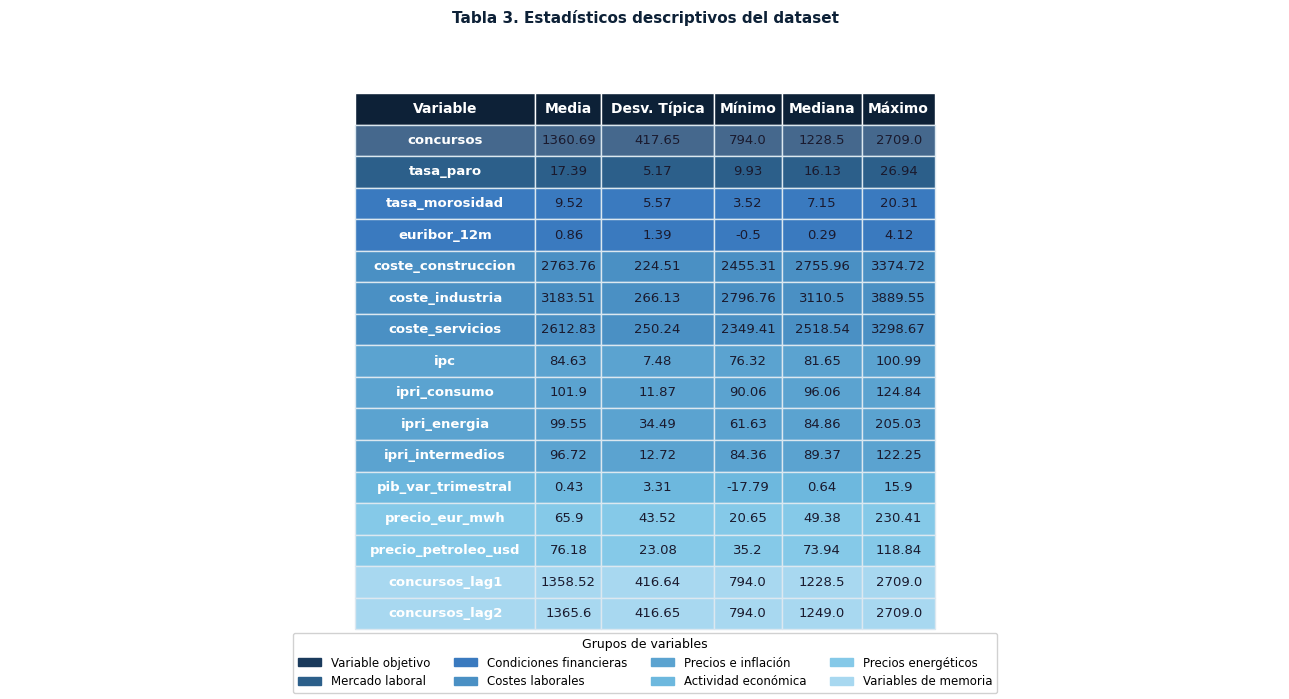

Tabla guardada


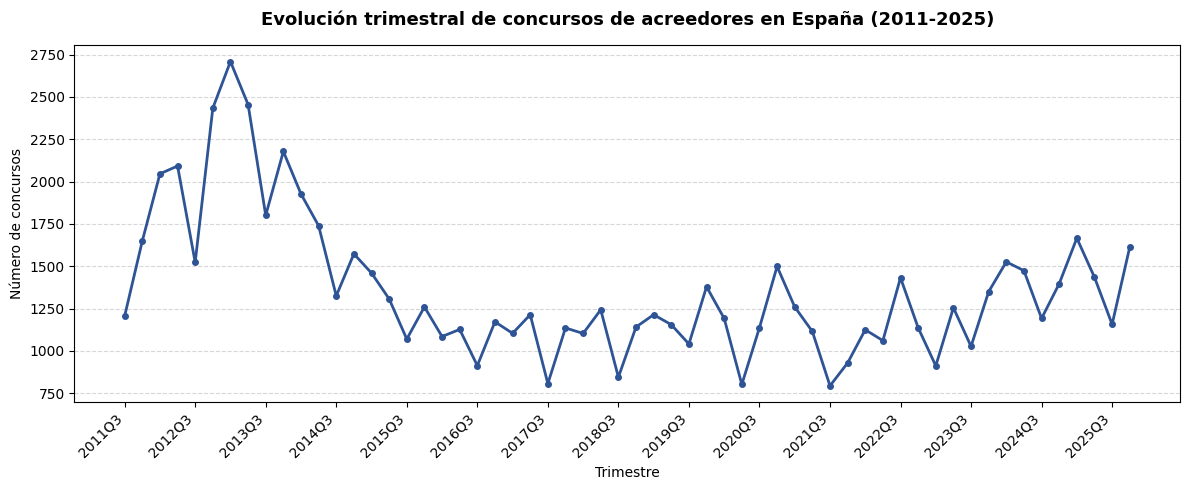

Gráfico guardado


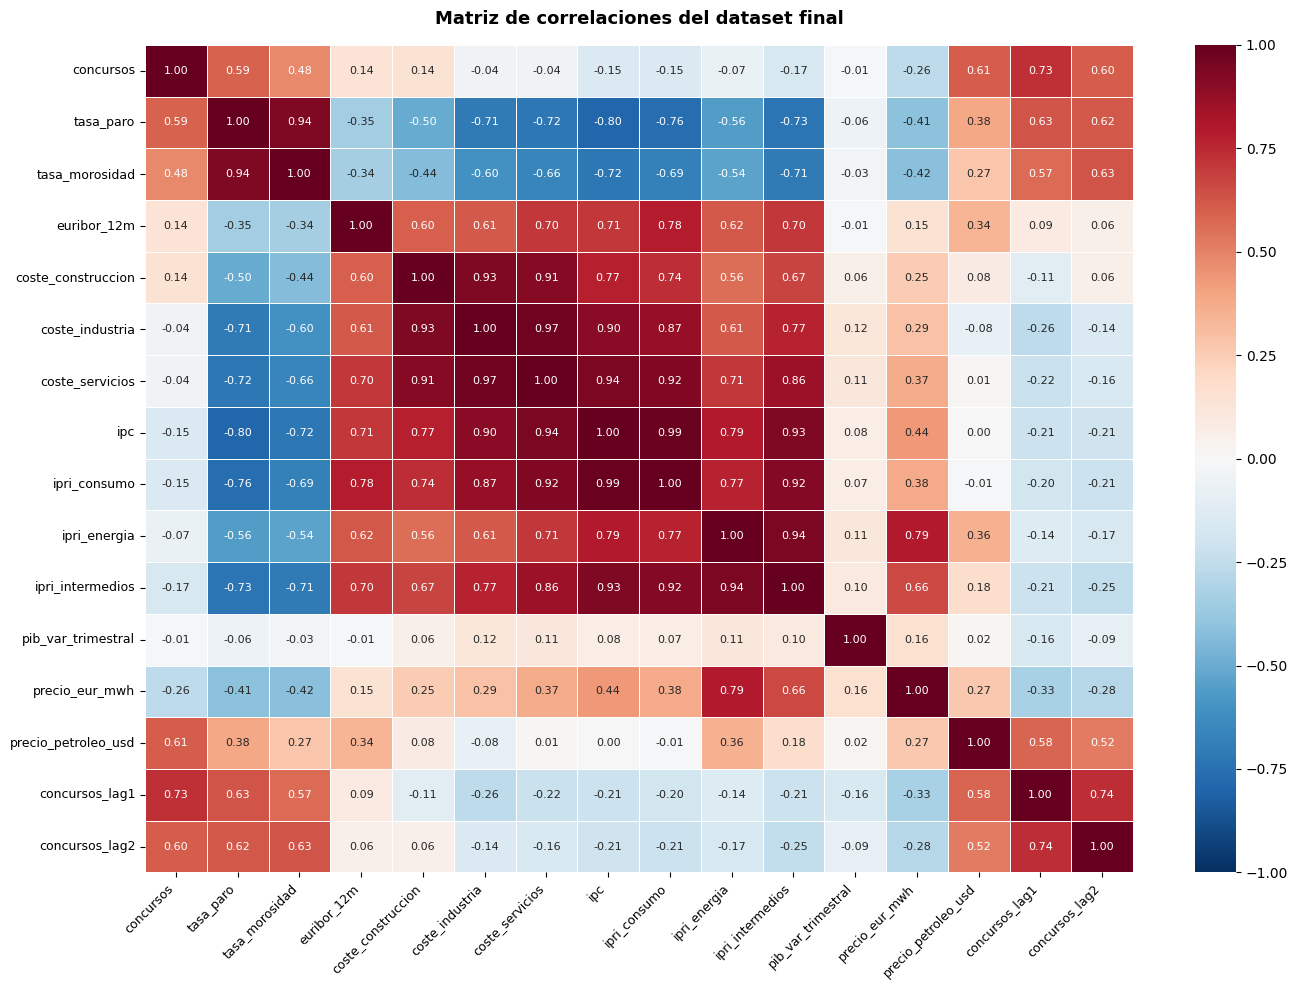

Correlaciones guardadas

TEST DE DICKEY-FULLER AUMENTADO — concursos
  Estadístico ADF : -4.8696
  p-valor         : 0.0000
  Valores críticos:
    1%: -3.5715
    5%: -2.9226
    10%: -2.5993
  → Serie ESTACIONARIA (se rechaza H0 de raíz unitaria)


In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
import subprocess
subprocess.run(['pip', 'install', 'statsmodels'], capture_output=True)

variables_num = df_final.drop(columns=['periodo'])

#  1. TABLA DESCRIPTIVA 
desc = variables_num.describe().T[['mean', 'std', 'min', '50%', 'max']]
desc.columns = ['Media', 'Desv. Típica', 'Mínimo', 'Mediana', 'Máximo']
desc = desc.round(2).reset_index().rename(columns={'index': 'Variable'})

grupos_color = {
    'concursos':            "#45688d",
    'tasa_paro':            '#2c5f8a',
    'tasa_morosidad':       '#3a7abf',
    'euribor_12m':          '#3a7abf',
    'coste_construccion':   '#4a90c4',
    'coste_industria':      '#4a90c4',
    'coste_servicios':      '#4a90c4',
    'ipc':                  '#5ba3d0',
    'ipri_consumo':         '#5ba3d0',
    'ipri_energia':         '#5ba3d0',
    'ipri_intermedios':     '#5ba3d0',
    'pib_var_trimestral':   '#6db8de',
    'precio_eur_mwh':       '#85c9e8',
    'precio_petroleo_usd':  '#85c9e8',
    'concursos_lag1':       '#a8d8f0',
    'concursos_lag2':       '#a8d8f0',
}

col_labels = list(desc.columns)
cell_text = [[str(v) for v in row] for row in desc.values]

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')

table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.6)

for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_facecolor('#0d2137')
    cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    cell.set_edgecolor('#ffffff')

for i, row in enumerate(desc['Variable']):
    color = grupos_color.get(row, '#cce4f5')
    for j in range(len(col_labels)):
        cell = table[i + 1, j]
        cell.set_facecolor(color)
        cell.set_text_props(
            color='white' if j == 0 else '#1a1a2e',
            fontweight='bold' if j == 0 else 'normal'
        )
        cell.set_edgecolor('#dce8f0')

table.auto_set_column_width(col=list(range(len(col_labels))))

leyenda = [
    mpatches.Patch(color='#1a3a5c', label='Variable objetivo'),
    mpatches.Patch(color='#2c5f8a', label='Mercado laboral'),
    mpatches.Patch(color='#3a7abf', label='Condiciones financieras'),
    mpatches.Patch(color='#4a90c4', label='Costes laborales'),
    mpatches.Patch(color='#5ba3d0', label='Precios e inflación'),
    mpatches.Patch(color='#6db8de', label='Actividad económica'),
    mpatches.Patch(color='#85c9e8', label='Precios energéticos'),
    mpatches.Patch(color='#a8d8f0', label='Variables de memoria'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=4, fontsize=8.5,
           framealpha=0.9, title='Grupos de variables', title_fontsize=9)

plt.title('Tabla 3. Estadísticos descriptivos del dataset',
          fontsize=11, fontweight='bold', pad=14, color='#0d2137')
plt.tight_layout()
plt.savefig('../data/graphics/fig_tabla_descriptivos.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Tabla guardada")


#  2. EVOLUCIÓN TEMPORAL DE CONCURSOS 
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_final['periodo'], df_final['concursos'],
        color='#2E5496', linewidth=2, marker='o', markersize=4)
ax.set_title('Evolución trimestral de concursos de acreedores en España (2011-2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de concursos')
ax.set_xticks(df_final['periodo'][::4])
ax.set_xticklabels(df_final['periodo'][::4], rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig('../data/graphics/fig_evolucion_concursos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

#  3. MATRIZ DE CORRELACIONES 
fig, ax = plt.subplots(figsize=(14, 10))
corr = variables_num.corr()
mask = corr.abs() < 0.1  # ocultar correlaciones muy bajas
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlaciones del dataset final', fontsize=13,
             fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../data/graphics/fig_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlaciones guardadas")

#  4. TEST DE ESTACIONARIEDAD (ADF) 
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df_final['concursos'], autolag='AIC')
print("\nTEST DE DICKEY-FULLER AUMENTADO — concursos")
print(f"  Estadístico ADF : {resultado[0]:.4f}")
print(f"  p-valor         : {resultado[1]:.4f}")
print(f"  Valores críticos:")
for clave, valor in resultado[4].items():
    print(f"    {clave}: {valor:.4f}")
if resultado[1] < 0.05:
    print("  → Serie ESTACIONARIA (se rechaza H0 de raíz unitaria)")
else:
    print("  → Serie NO ESTACIONARIA (no se rechaza H0)")

## Outliers y mas graficos 

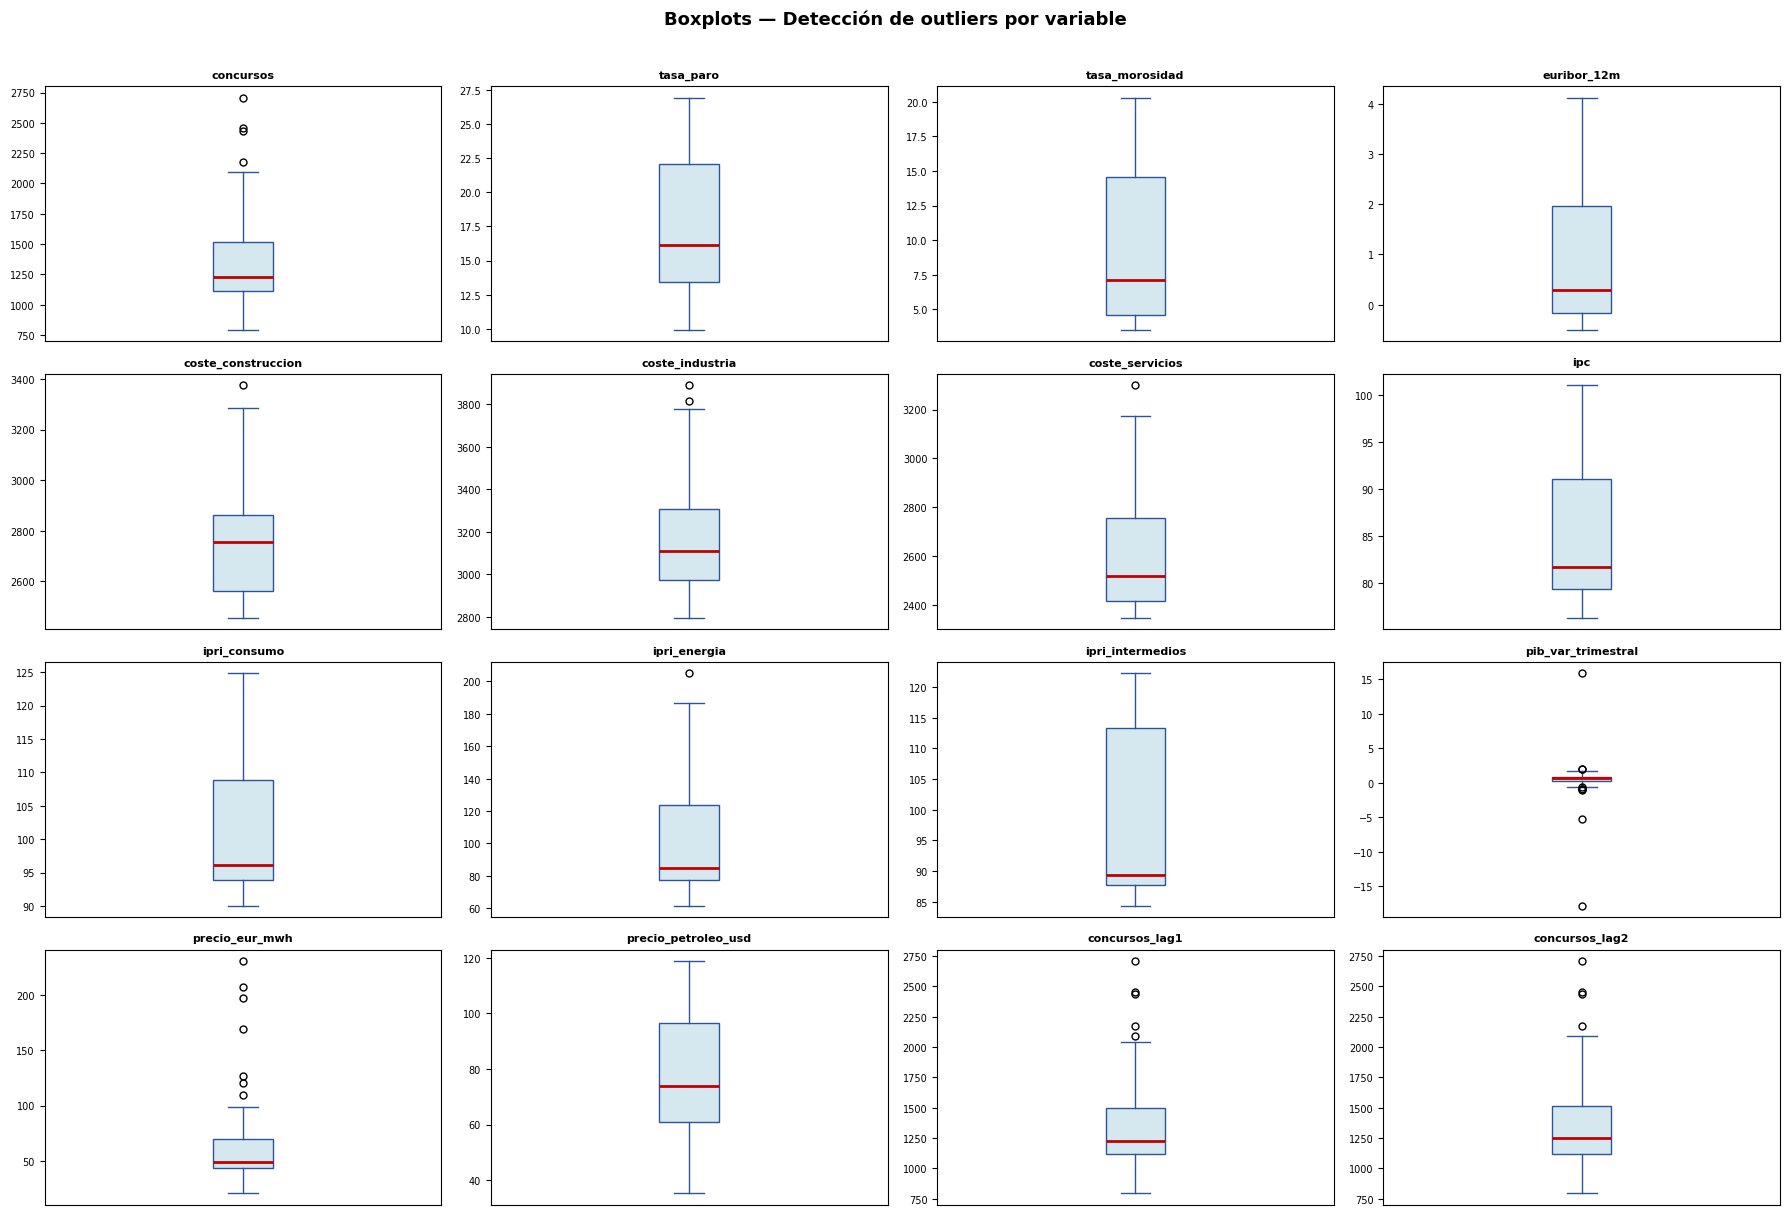

Boxplots guardados


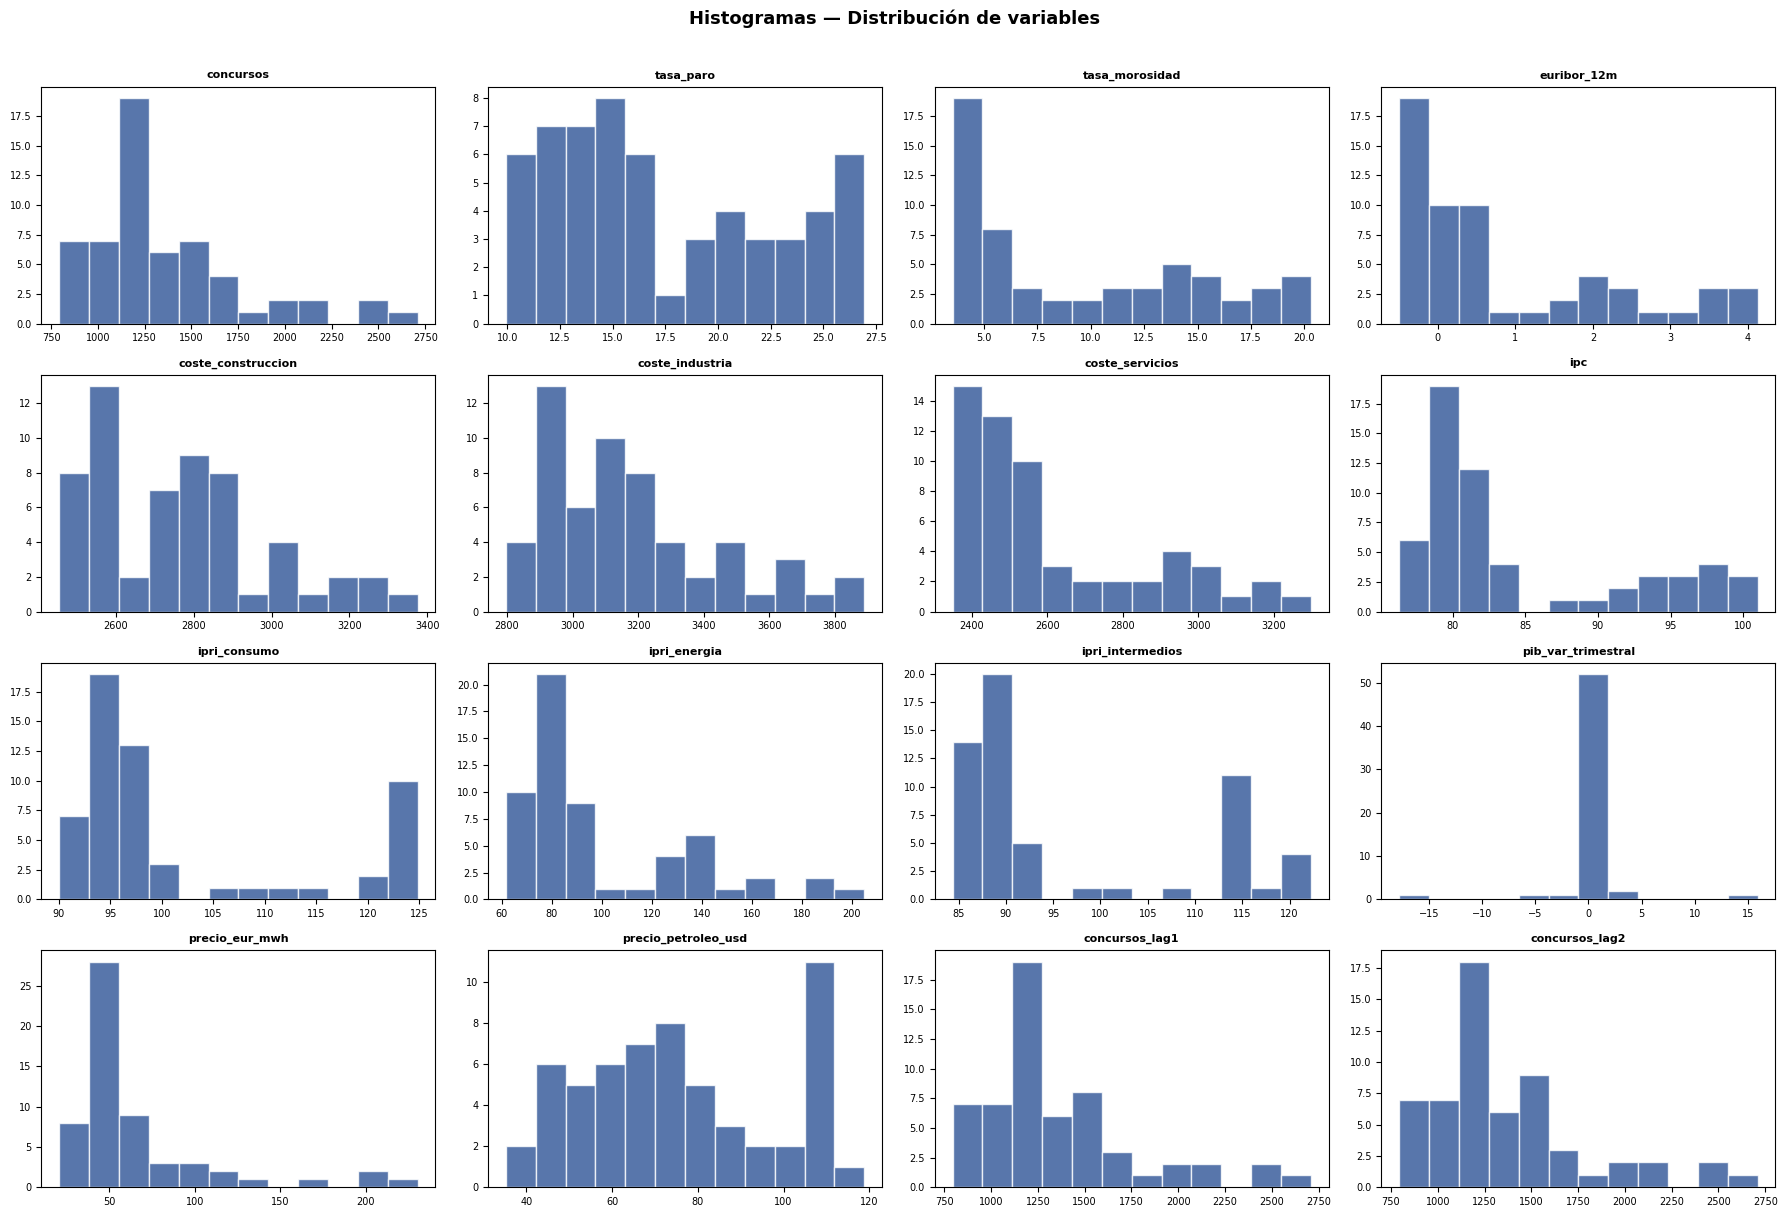

Histogramas guardados


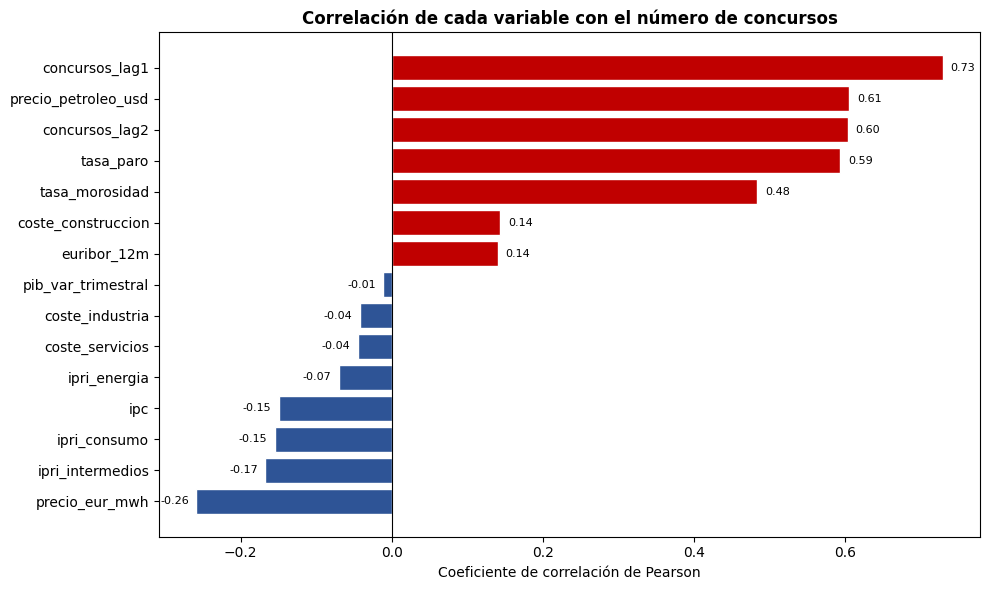

Gráfico correlaciones con target guardado


In [44]:
#  5. ANÁLISIS DE OUTLIERS (boxplots)
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

cols = [c for c in df_final.columns if c != 'periodo']
for i, col in enumerate(cols):
    axes[i].boxplot(df_final[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#D5E8F0', color='#2E5496'),
                    medianprops=dict(color='#C00000', linewidth=2),
                    whiskerprops=dict(color='#2E5496'),
                    capprops=dict(color='#2E5496'),
                    flierprops=dict(marker='o', color='#C00000', markersize=5))
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].set_xticks([])

# Ocultar el último subplot si sobra
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Detección de outliers por variable', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/graphics/fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Boxplots guardados")

#  6. HISTOGRAMAS 
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df_final[col].dropna(), bins=12, color='#2E5496', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=7)

for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas — Distribución de variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/graphics/fig_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogramas guardados")

#  7. CORRELACIÓN DE VARIABLES CON CONCURSOS (barras) 
corr_target = variables_num.corr()['concursos'].drop('concursos').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#C00000' if v > 0 else '#2E5496' for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada variable con el número de concursos', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente de correlación de Pearson')
for i, (v, name) in enumerate(zip(corr_target.values, corr_target.index)):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../data/graphics/fig_correlacion_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico correlaciones con target guardado")

## TEST DE ESTACIONARIEDAD 


TEST DE DICKEY-FULLER AUMENTADO — concursos
  Estadístico ADF : -4.8696
  p-valor         : 0.0000
  Valores críticos:
    1%: -3.5715
    5%: -2.9226
    10%: -2.5993
  → Serie ESTACIONARIA (se rechaza H0 de raíz unitaria)


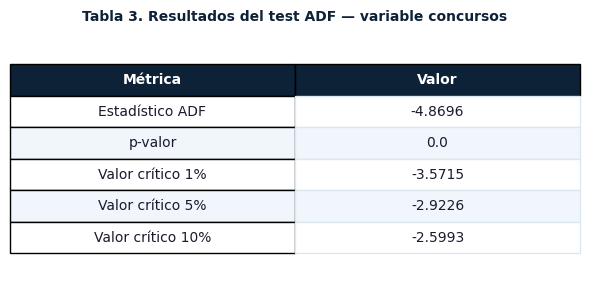

Tabla ADF guardada


In [45]:
# ─  TEST DE ESTACIONARIEDAD (ADF) 
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df_final['concursos'], autolag='AIC')
print("\nTEST DE DICKEY-FULLER AUMENTADO — concursos")
print(f"  Estadístico ADF : {resultado[0]:.4f}")
print(f"  p-valor         : {resultado[1]:.4f}")
print(f"  Valores críticos:")
for clave, valor in resultado[4].items():
    print(f"    {clave}: {valor:.4f}")
if resultado[1] < 0.05:
    print("  → Serie ESTACIONARIA (se rechaza H0 de raíz unitaria)")
else:
    print("  → Serie NO ESTACIONARIA (no se rechaza H0)")

# Tabla visual ADF
adf_data = {
    'Métrica': ['Estadístico ADF', 'p-valor',
                'Valor crítico 1%', 'Valor crítico 5%', 'Valor crítico 10%'],
    'Valor': [round(resultado[0], 4), round(resultado[1], 4),
              round(resultado[4]['1%'], 4),
              round(resultado[4]['5%'], 4),
              round(resultado[4]['10%'], 4)]
}
df_adf = pd.DataFrame(adf_data)

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
table = ax.table(cellText=df_adf.values, colLabels=df_adf.columns,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

for j in range(2):
    table[0, j].set_facecolor('#0d2137')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(df_adf) + 1):
    color = '#f0f6fb' if i % 2 == 0 else '#ffffff'
    for j in range(2):
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='#1a1a2e')
    table[i, j].set_edgecolor('#dce8f0')

plt.title('Tabla 3. Resultados del test ADF — variable concursos',
          fontsize=10, fontweight='bold', pad=12, color='#0d2137')
plt.tight_layout()
plt.savefig('../data/graphics/tabla_adf.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Tabla ADF guardada")

## Diccionario de variables

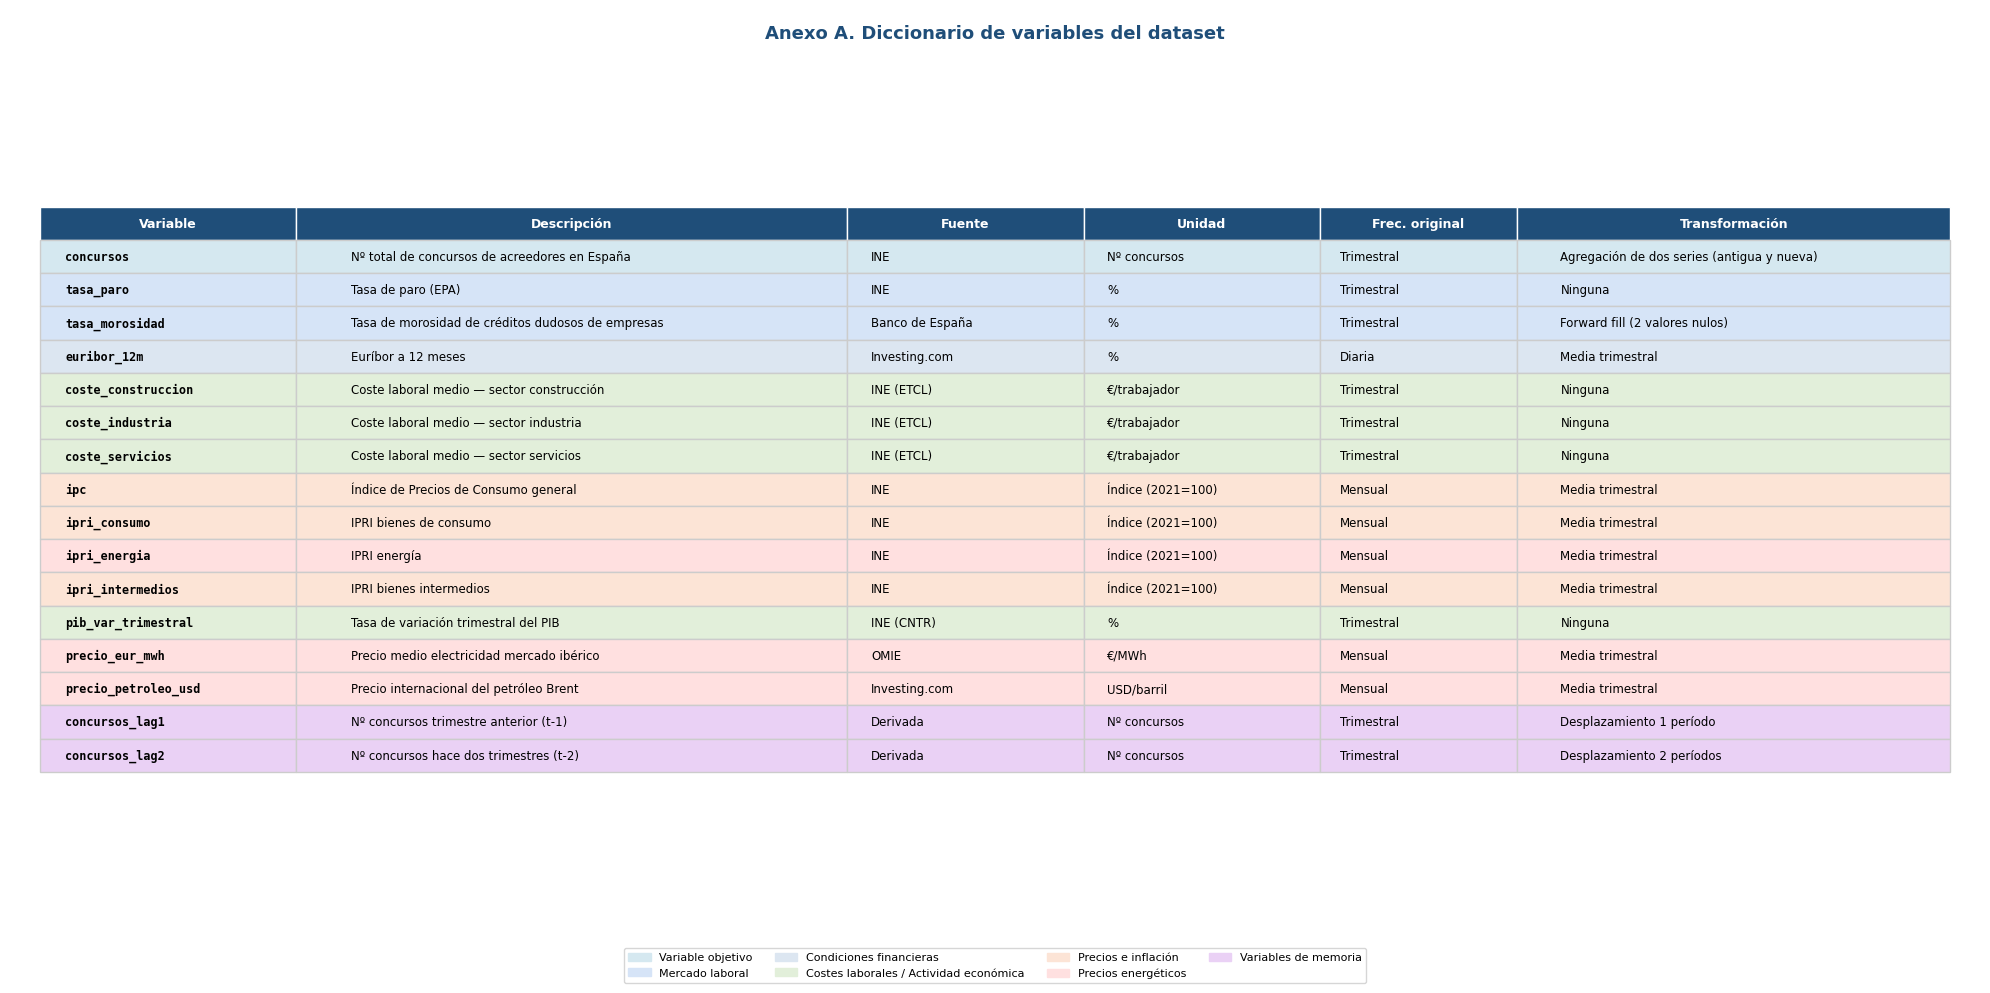

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

data = [
    ["concursos", "Nº total de concursos de acreedores en España", "INE", "Nº concursos", "Trimestral", "Agregación de dos series (antigua y nueva)"],
    ["tasa_paro", "Tasa de paro (EPA)", "INE", "%", "Trimestral", "Ninguna"],
    ["tasa_morosidad", "Tasa de morosidad de créditos dudosos de empresas", "Banco de España", "%", "Trimestral", "Forward fill (2 valores nulos)"],
    ["euribor_12m", "Euríbor a 12 meses", "Investing.com", "%", "Diaria", "Media trimestral"],
    ["coste_construccion", "Coste laboral medio — sector construcción", "INE (ETCL)", "€/trabajador", "Trimestral", "Ninguna"],
    ["coste_industria", "Coste laboral medio — sector industria", "INE (ETCL)", "€/trabajador", "Trimestral", "Ninguna"],
    ["coste_servicios", "Coste laboral medio — sector servicios", "INE (ETCL)", "€/trabajador", "Trimestral", "Ninguna"],
    ["ipc", "Índice de Precios de Consumo general", "INE", "Índice (2021=100)", "Mensual", "Media trimestral"],
    ["ipri_consumo", "IPRI bienes de consumo", "INE", "Índice (2021=100)", "Mensual", "Media trimestral"],
    ["ipri_energia", "IPRI energía", "INE", "Índice (2021=100)", "Mensual", "Media trimestral"],
    ["ipri_intermedios", "IPRI bienes intermedios", "INE", "Índice (2021=100)", "Mensual", "Media trimestral"],
    ["pib_var_trimestral", "Tasa de variación trimestral del PIB", "INE (CNTR)", "%", "Trimestral", "Ninguna"],
    ["precio_eur_mwh", "Precio medio electricidad mercado ibérico", "OMIE", "€/MWh", "Mensual", "Media trimestral"],
    ["precio_petroleo_usd", "Precio internacional del petróleo Brent", "Investing.com", "USD/barril", "Mensual", "Media trimestral"],
    ["concursos_lag1", "Nº concursos trimestre anterior (t-1)", "Derivada", "Nº concursos", "Trimestral", "Desplazamiento 1 período"],
    ["concursos_lag2", "Nº concursos hace dos trimestres (t-2)", "Derivada", "Nº concursos", "Trimestral", "Desplazamiento 2 períodos"],
]

columns = ["Variable", "Descripción", "Fuente", "Unidad", "Frec. original", "Transformación"]
col_widths = [0.13, 0.28, 0.12, 0.12, 0.10, 0.22]

row_bg = [
    '#D5E8F0',  # concursos - variable objetivo
    '#D6E4F7',  # mercado laboral
    '#D6E4F7',
    '#DCE6F1',  # condiciones financieras
    '#E2EFDA',  # costes laborales
    '#E2EFDA',
    '#E2EFDA',
    '#FCE4D6',  # precios e inflación
    '#FCE4D6',
    '#FFE0E0',  # precios energéticos
    '#FCE4D6',
    '#E2EFDA',  # actividad económica
    '#FFE0E0',  # precios energéticos
    '#FFE0E0',
    '#EAD1F5',  # variables de memoria
    '#EAD1F5',
]

fig, ax = plt.subplots(figsize=(20, 10))
ax.axis('off')

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='left',
    loc='center',
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.6)

# Header
for j in range(len(columns)):
    cell = table[0, j]
    cell.set_facecolor('#1F4E79')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)
    cell.set_edgecolor('white')

# Filas
for i in range(len(data)):
    for j in range(len(columns)):
        cell = table[i+1, j]
        cell.set_facecolor(row_bg[i])
        cell.set_edgecolor('#CCCCCC')
        cell.set_text_props(fontsize=8.5)
        if j == 0:
            cell.set_text_props(fontweight='bold', fontsize=8.5, fontfamily='monospace')

# Leyenda
legend_items = [
    (mpatches.Patch(color='#D5E8F0'), 'Variable objetivo'),
    (mpatches.Patch(color='#D6E4F7'), 'Mercado laboral'),
    (mpatches.Patch(color='#DCE6F1'), 'Condiciones financieras'),
    (mpatches.Patch(color='#E2EFDA'), 'Costes laborales / Actividad económica'),
    (mpatches.Patch(color='#FCE4D6'), 'Precios e inflación'),
    (mpatches.Patch(color='#FFE0E0'), 'Precios energéticos'),
    (mpatches.Patch(color='#EAD1F5'), 'Variables de memoria'),
]
handles = [item[0] for item in legend_items]
labels = [item[1] for item in legend_items]
ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02),
          ncol=4, fontsize=8, frameon=True, edgecolor='#CCCCCC')

plt.tight_layout()
plt.savefig('anexo_diccionario_variables.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()